In [1]:
#Upload data from drive
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
drive_path = '/content/drive/My Drive/Programacion/Actuary/freMTPL2/'
df_freq = pd.read_csv(drive_path + 'freMTPL2freq.csv')  #Frequency
df_sev = pd.read_csv(drive_path + 'freMTPL2sev.csv')    #Severity

Mounted at /content/drive


In [ ]:
#Extra Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset frecuencia:** Registra los datos de cada cliente, que auto tiene, donde vive y durante cuanto tiempo estuvo cubierto (Exposure)

La variable "ClaimNb" es la cantidad de siniestros. Cuantas veces esa poliza en particular reclamó un choque durante su tiempo activa.

**Dataset severidad:** Solo contiene informacion de los accidentes que costaron dinero. Cada fila es un siniestro individual que ya ocurrió y que la empresa tuvo que pagar.

In [45]:
print("------Severity data------")
print(df_sev.head(3))
print("\n------Frequency data------")
print(df_freq.head(5))

------Severity data------
     IDpol  ClaimAmount
0     1552       995,20
1  1010996     1.128,12
2  4024277     1.851,11

------Frequency data------
   IDpol  ClaimNb  Exposure  VehPower  VehAge  DrivAge  BonusMalus VehBrand  \
0   1,00        1      0,10         5       0       55          50      B12   
1   3,00        1      0,77         5       0       55          50      B12   
2   5,00        1      0,75         6       2       52          50      B12   
3  10,00        1      0,09         7       0       46          50      B12   
4  11,00        1      0,84         7       0       46          50      B12   

    VehGas Area  Density       Region  
0  Regular    D     1217  Rhone-Alpes  
1  Regular    D     1217  Rhone-Alpes  
2   Diesel    B       54     Picardie  
3   Diesel    B       76    Aquitaine  
4   Diesel    B       76    Aquitaine  


In [110]:
total_exposure = df_freq['Exposure'].sum()
total_claims = df_freq['ClaimNb'].sum()
portfolio_frequency = total_claims / total_exposure
print(f"Total pólizas    : {len(df_freq)}")
print(f"Total siniestros :  {total_claims}      siniestros")
print(f"Exposición total : {total_exposure.sum():.2f}  años poliza ")
print(f'Frecuencia media : {portfolio_frequency * 100:.2f}%     [ Siniestros / Exposición ]')

Total pólizas    : 678013
Total siniestros :  36102      siniestros
Exposición total : 358499.45  años poliza 
Frecuencia media : 10.07%     [ Siniestros / Exposición ]


In [113]:
total_claim_amount = df_sev['ClaimAmount'].sum()
global_severity = total_claim_amount / total_claims
print(f"Costo Total de Siniestros  : €{total_claim_amount:,.2f}")
print(f"Severidad Media Global     : {global_severity:,.2f}")

Costo Total de Siniestros  : €60,697,930.68
Severidad Media Global     : 1,681.29


/tmp/ipykernel_1838/1384905486.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


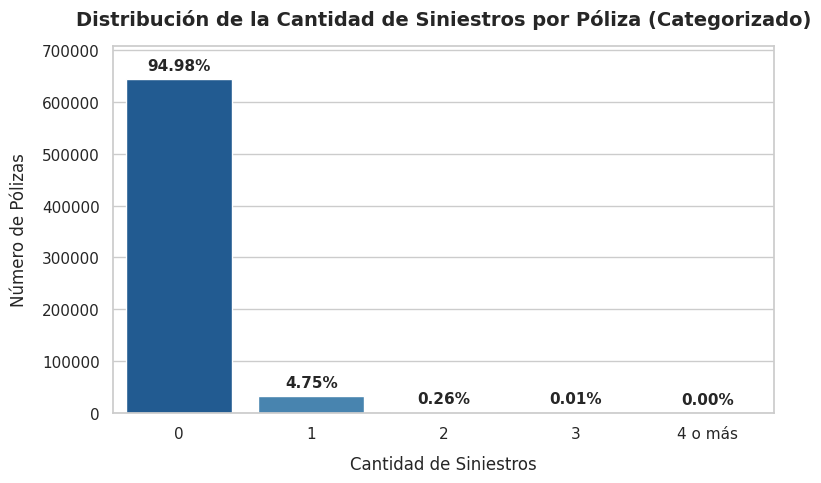

In [129]:
# ==============================================================================
# GRAFICO: DISTRIBUCIÓN DE FRECUENCIA AGRUPADA
# ==============================================================================
def agrupar_siniestros(x):
    if x >= 4:
        return '4 o más'
    return str(x)
# Aplicamos la función en una columna nueva del dataframe
df_freq['ClaimNb_Grouped'] = df_freq['ClaimNb'].apply(agrupar_siniestros)
# Definimos el orden exacto en el que queremos que aparezcan las barras
orden_eje_x = ['0', '1', '2', '3', '4 o más']
# 2. Armamos el gráfico independiente
plt.figure(figsize=(8, 5))
# Usamos una paleta de azules que vaya de oscuro (más común) a claro (menos común)
ax = sns.countplot(
    data=df_freq,
    x='ClaimNb_Grouped',
    order=orden_eje_x,
    palette='Blues_r'
)
# 3. Estética y etiquetas
plt.title('Distribución de la Cantidad de Siniestros por Póliza (Categorizado)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Siniestros', fontsize=12, labelpad=10)
plt.ylabel('Número de Pólizas', fontsize=12, labelpad=10)

# Añadimos los porcentajes arriba de cada barra con formato local (, para decimales)
total_polizas = len(df_freq)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total_polizas:.2f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=11,
        fontweight='semibold'
    )
# Ajustamos los límites del eje Y para dejar espacio a las etiquetas de porcentaje
plt.ylim(0, df_freq['ClaimNb_Grouped'].value_counts().max() * 1.1)

plt.tight_layout()
plt.show()

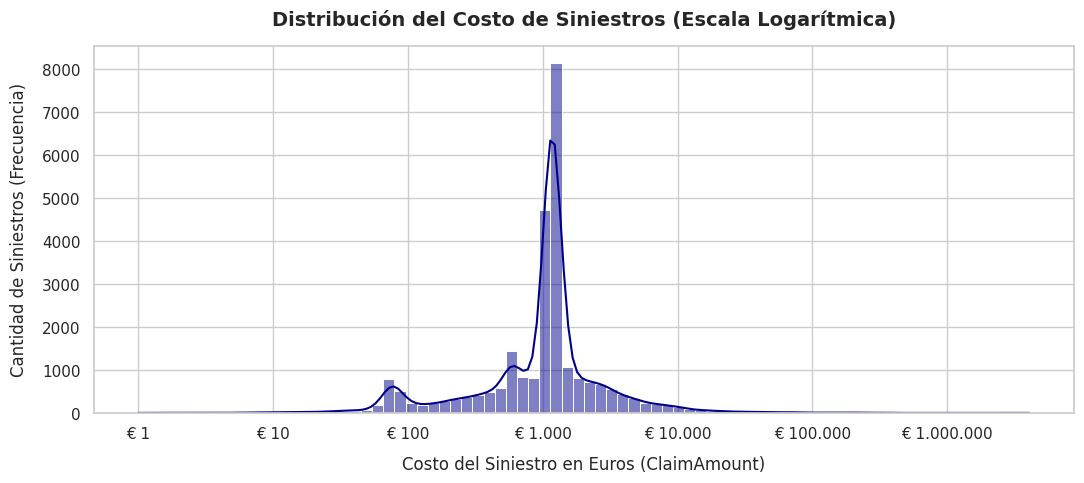

In [128]:
# ==============================================================================
# GRAFICO: DISTRIBUCIÓN DE SEVERIDAD (COSTO DE SINIESTROS)
# ==============================================================================
plt.figure(figsize=(11, 5))

# Dibujamos el histograma (se mantiene igual, impecable)
ax = sns.histplot(
    data=df_sev,
    x='ClaimAmount',
    bins=80,
    kde=True,
    color='darkblue',
    log_scale=True
)

plt.title('Distribución del Costo de Siniestros (Escala Logarítmica)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Costo del Siniestro en Euros (ClaimAmount)', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Siniestros (Frecuencia)', fontsize=12, labelpad=10)

# --- REPARACIÓN DEL EJE X ---
# Avanzamos multiplicando por 10. Esto garantiza la simetría visual en log-scale.
ticks_euros = [1, 10, 100, 1000, 10000, 100000, 1000000]

# Formateamos las etiquetas en Euros con formato local argentino
labels_euros = [f"€ {t:,}".replace(',', '.') for t in ticks_euros]

# Aplicamos los ticks corregidos (rotación a 0 porque ahora hay espacio de sobra)
plt.xticks(ticks_euros, labels_euros, rotation=0)

plt.tight_layout()
plt.show()

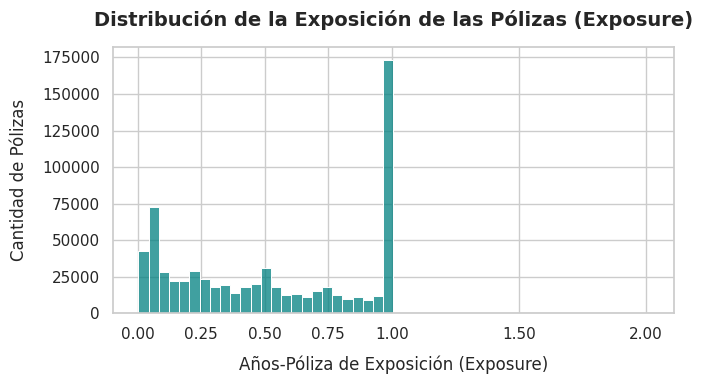

In [123]:
# ==============================================================================
# GRAFICO: ANÁLISIS DE LA EXPOSICIÓN (EXPOSURE)
# ==============================================================================
plt.figure(figsize=(7, 4))

# Dibujamos el histograma de la exposición
ax = sns.histplot(
    data=df_freq,
    x='Exposure',
    bins=50,
    kde=False,
    color='teal'
)

plt.title('Distribución de la Exposición de las Pólizas (Exposure)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Años-Póliza de Exposición (Exposure)', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Pólizas', fontsize=12, labelpad=10)

# Forzamos los ticks del eje X para ver bien los puntos clave (0, 0.5, 1, 2)
plt.xticks([0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0])

plt.tight_layout()
plt.show()